# 1. Background

Supermart, Inc. is a retail supermarket company that provides a wide range of daily consumer products, including fresh food, household essentials, and premium goods such as wine and meat. Supermart exists to fulfill customers’ daily needs by offering convenient access to essential goods, while also providing variety, quality, and competitive pricing. Supermart generates revenue primarily through product sales across multiple categories, such as food & beverages (e.g., meat, fruits, wine), household products, and premium/lifestyle items.

This analysis supports multiple stakeholders across the organization. The CEO uses it for strategic decision-making, while the marketing team leverages customer segmentation to improve campaign targeting and effectiveness. The sales and operations team apply these insights to optimize in-store promotions and inventory, and the product team uses them to design better product offerings and bundles. Overall, this analysis enables more data-driven decisions across the business.

In the modern retail industry, supermarkets collect large volumes of customer data from transactions, marketing campaigns, and purchasing channels. Customer insights are essential for supermarkets to remain competitive. By analyzing customer demographics, purchasing habits, and campaign responses, businesses can identify valuable customer segments and design targeted marketing strategies that improve sales and customer retention.

This project analyzes a supermarket customer dataset that contains demographic information, purchasing activity across multiple product categories, and customer responses to marketing campaigns. Through data analysis and visualization, the project aims to uncover patterns in customer behavior and identify opportunities for improving marketing strategies and product focus.

# 2. Business Statement
The supermarket aims to improve its marketing effectiveness and better understand customer purchasing behavior. While the company currently runs multiple marketing campaigns across various product categories, it lacks clarity on which customer segments generate the most value and how different segments respond to marketing efforts.

Therefore, this analysis focuses on segmenting customers based on demographics, shopping behavior, and campaign responses to identify meaningful patterns in spending and engagement.

The objective is to determine how different customer segments contribute to revenue and how they respond to marketing campaigns, in order to enable more targeted and effective marketing strategies. How can customer segmentation based on demographics, shopping behavior, and campaign responses be used to develop more targeted and effective marketing strategies? This question will trigger supporting questions like which product categories drive the most spending across different customer segments, how do demographic factors influence segment behavior, which segments respond best to marketing campaigns, which channels are preferred by different segments, and many more.

The insights from this analysis will help the supermarket optimize campaign targeting, prioritize high-value segments, and improve overall marketing performance.

# 3. Data Overview
The dataset used in this project contains information about supermarket customers, including their demographic characteristics, purchasing activity, and responses to marketing campaigns.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [24]:
df=pd.read_csv('Supermarket Customers.csv', sep="\t")

display(df.head(),df.tail())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,3,61,2,1,21,3,3,1,4,7,0,0,0,0,0,0,3,11,1


Each row represents an individual customer, while the columns describe various aspects of the customer's profile and behavior.

1. Customer Demographics

These variables describe the personal characteristics of each customer.
Examples include:
- Year_Birth – customer’s birth year
- Education – highest education level
- Marital_Status – marital status
- Income – yearly household income
- Kidhome – number of children in the household
- Teenhome – number of teenagers in the household

2. Customer Spending Behavior

These variables record the amount spent by customers on different product categories over the last two years.
Examples include:
- MntWines
- MntFruits
- MntMeatProducts
- MntFishProducts
- MntSweetProducts
- MntGoldProds

3. Purchase Channels

These variables describe how customers make purchases.
Examples include:
- NumWebPurchases
- NumCatalogPurchases
- NumStorePurchases
- NumWebVisitsMonth

4. Marketing Campaign Response

These variables indicate whether customers accepted previous marketing campaigns.
Examples include:
- AcceptedCmp1 to AcceptedCmp5
- Response (response to the most recent campaign)

This dataset provides a comprehensive view of customer behavior and marketing outcomes, making it suitable for analyzing purchasing patterns and marketing effectiveness.

# 4. Data Understanding and Cleaning
Before conducting the analysis, it is important to examine the dataset to understand its structure, identify potential data quality issues, and prepare the data for analysis.

## 4.1 Data Structure and Initial Observation

Initial exploration of the dataset was conducted using functions such as:
- df.info() to inspect data types
- df.describe() to examine statistical summaries
- unique value check

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [26]:
display(df.describe(), df.describe(include='object'))
pd.set_option('display.max_columns', None)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


In [27]:
pd.set_option('display.max_colwidth', None)

# unique data on each column
listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), df[col].unique()])

table1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=listItem)
table1Desc

,Column Name,Number of Unique,Unique Sample
0,ID,2240,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177, 4855, 5899, 1994, 387, 2125, 8180, 2569, 2114, 9736, 4939, 6565, 2278, 9360, 5376, 1993, 4047, 1409, 7892, 2404, 5255, 9422, 1966, 6864, 3033, 5710, 7373, 8755, 10738, 4339, 10755, 8595, 2968, 8601, 503, 8430, 7281, 2139, 1371, 9909, 7286, 7244, 6566, 8614, 4114, 1331, 2225, 9381, 6260, 10383, 7437, 8557, 8375, 6853, 3076, 1012, 6518, 4137, 8082, 1386, 9369, 4477, 1357, 1402, 10629, 6312, 8132, 1050, 5846, 1859, 7503, 10401, 1618, 3332, 2261, 5346, 4119, 535, 5268, 273, 4452, 8504, 771, 8996, 9235, 5798, 11178, 2230, 7516, 7247, 11100, 4646, 3037, ...]"
1,Year_Birth,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 1985, 1974, 1950, 1983, 1976, 1959, 1952, 1987, 1946, 1980, 1949, 1982, 1979, 1951, 1969, 1986, 1989, 1963, 1970, 1973, 1943, 1975, 1996, 1968, 1964, 1977, 1978, 1955, 1966, 1988, 1948, 1958, 1972, 1960, 1945, 1991, 1962, 1953, 1961, 1956, 1992, 1900, 1893, 1990, 1947, 1899, 1993, 1994, 1941, 1944, 1995, 1940]"
2,Education,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
3,Marital_Status,8,"[Single, Together, Married, Divorced, Widow, Alone, Absurd, YOLO]"
4,Income,1974,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, 62513.0, 55635.0, 33454.0, 30351.0, 5648.0, nan, 7500.0, 63033.0, 59354.0, 17323.0, 82800.0, 41850.0, 37760.0, 76995.0, 33812.0, 37040.0, 2447.0, 58607.0, 65324.0, 40689.0, 18589.0, 53359.0, 38360.0, 84618.0, 10979.0, 38620.0, 40548.0, 46610.0, 68657.0, 49389.0, 67353.0, 23718.0, 42429.0, 48948.0, 80011.0, 20559.0, 21994.0, 79941.0, 41728.0, 72550.0, 65486.0, 79143.0, 35790.0, 82582.0, 66373.0, 82384.0, 70287.0, 27938.0, 55954.0, 75777.0, 66653.0, 61823.0, 67680.0, 70666.0, 25721.0, 32474.0, 88194.0, 69096.0, 74854.0, 66991.0, 65031.0, 60631.0, 28332.0, 40246.0, 75251.0, 75825.0, 26326.0, 56046.0, 29760.0, 26304.0, 23559.0, 81361.0, 29440.0, 36138.0, 50388.0, 79593.0, 54178.0, 42394.0, 23626.0, 30096.0, 47916.0, 51813.0, 78497.0, 50150.0, 47823.0, 34554.0, 85693.0, 65846.0, 87195.0, 24594.0, 49096.0, 52413.0, 38557.0, 89058.0, 77298.0, ...]"
5,Kidhome,3,"[0, 1, 2]"
6,Teenhome,3,"[0, 1, 2]"
7,Dt_Customer,663,"[04-09-2012, 08-03-2014, 21-08-2013, 10-02-2014, 19-01-2014, 09-09-2013, 13-11-2012, 08-05-2013, 06-06-2013, 13-03-2014, 15-11-2013, 10-10-2012, 24-11-2012, 24-12-2012, 31-08-2012, 28-03-2013, 03-11-2012, 08-08-2012, 06-01-2013, 23-12-2012, 11-01-2014, 18-03-2013, 02-01-2013, 27-05-2013, 20-02-2013, 31-05-2013, 22-11-2013, 22-05-2014, 11-05-2013, 29-10-2012, 29-08-2013, 31-12-2013, 02-09-2013, 11-02-2014, 01-02-2013, 29-04-2013, 12-03-2013, 05-11-2013, 02-10-2013, 28-06-2014, 09-11-2012, 24-05-2013, 01-01-2014, 08-11-2012, 12-05-2014, 11-08-2012, 07-06-2014, 12-06-2013, 19-11-2012, 02-04-2013, 28-04-2014, 17-06-2013, 03-03-2014, 04-07-2013, 07-09-2012, 18-02-2013, 11-06-2013, 06-12-2013, 21-05-2013, 11-05-2014, 19-03-2014, 27-09-2013, 08-04-2013, 11-09-2012, 14-09-2012, 17-03-2013, 05-04-2013, 30-04-2014, 19-12-2012, 27-08-2012, 12-10-2012, 04-09-2013, 29-08-2012, 23-06-2013, 03-07-2013, 25-02-2014, 11-08-2013, 16-07-2013, 28-05-2014, 21-01-2014, 27-05-2014, 23-11-2013, 23-03-2014, 24-05-2014, 22-11-2012, 11-04-2013, 01-12-2013, 20-06-2013, 23-07-2013, 30-03-2014, 20-04-2013, 17-05-2013, 08-05-2014, 10-12-2013, 24-09-2013, 02-02-2013, 07-12-2012, 02-11-2013, 10-11-2012, 25-06-2014, ...]"
8,Recency,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 11, 59, 82, 53, 23, 51, 20, 91, 86, 41, 42, 63, 0, 69, 89, 4, 96, 56, 31, 8, 55, 37, 76, 99, 3, 88, 80, 72, 24, 92, 39, 29, 2, 54, 57, 30, 12, 18, 75, 90, 1, 25, 40, 9, 87, 5, 95, 48, 70, 79, 45, 84, 44, 43, 35, 15, 17, 46, 27, 74, 85, 65, 13, 83, 10, 21, 61, 73, 47, 36, 49, 28, 64, 98, 78, 77, 81, 14, 52, 93, 50, 60, 66, 97, 62, 6, 33, 67, 22, 71, 7]"
9,MntWines,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 5, 6, 194, 233, 3, 1006, 53, 84, 1012, 4, 86, 1, 867, 384, 270, 36, 684, 8, 112, 110, 96, 482, 40, 702, 55, 437, 421, 13, 9, 81, 123, 48, 826, 245, 650, 12, 510, 3

Based on the initial exploration using df.info(), df.describe(), and unique value checking, several observations can be made regarding the structure and quality of the dataset.

In general, we can observe the following:
- The Supermarket Customers dataset contains 29 columns and 2240 rows, where each row represents a single customer and each column represents a specific attribute related to the customer’s demographic information, purchasing behavior, or marketing campaign response.
- Most columns already have appropriate data types, with numerical variables stored as int64 or float64, and categorical variables such as Education and Marital_Status stored as object.
- The smallest number on Year_Birth is 1893. This could be an outlier (if we consider that the current year is 2026), so we will keep that in mind.
- The Income column contains several missing values represented by NaN, which need to be handled before further analysis since income is an important variable that may influence purchasing behavior.
- The Dt_Customer column represents the date when a customer first enrolled with the company. However, it is currently stored as an object data type and should be converted into a datetime format to allow time-based analysis.
- The dataset includes several columns that represent customer spending across different product categories, such as MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, and MntGoldProds. These columns can be combined into a new variable representing the total spending per customer.
- The columns Kidhome and Teenhome represent the number of children and teenagers in a household. These variables can be combined into a single feature to represent the total number of children in the household, which may influence purchasing behavior.
- The columns Z_CostContact and Z_Revenue contain constant values for all rows. Since they do not provide additional information for analysis, these columns can be removed from the dataset.

Based on these initial observations, several data cleaning and preparation steps will be performed:
1. Handling missing values in the Income column.
2. Converting the Dt_Customer column into datetime format.
3. Duplicate check.
4. Outlier check.
5. Removing irrelevant or non-informative columns such as ID, Z_CostContact, and Z_Revenue.

These steps are necessary to ensure that the dataset is clean, consistent, and ready for further analysis.

## 4.2 Missing Value

The missing value check revealed that all columns are filled, except for the Income column. It contains several missing values.

In [28]:
# percentage of missing value on each column
df.isna().sum()/df.shape[0]*100

ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Complain               0.000000
Z_CostContact          0.000000
Z_Revenue              0.000000
Response               0.000000
dtype: float64

Since income is an important variable for analyzing purchasing behavior, the missing values were handled by replacing them with the median income. The median was chosen instead of the mean because income distributions are often skewed and the median provides a more robust central value. Afterwards, let's confirm that the column is all filled.

In [29]:
df["Income"] = df["Income"].fillna(df["Income"].median())
print(df["Income"].isna().sum())

0


## 4.3 Data Type Adjustment
The Dt_Customer column, which represents the date when a customer joined the company, was originally stored as a string. To enable time-based analysis, it was converted into a datetime format. Afterwards, let's confirm the data type is changed.

In [30]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
df["Dt_Customer"].dtype

dtype('<M8[ns]')

## 4.4 Duplicate Check

Duplicate rows were checked to ensure data quality. No duplicate records were found in the dataset, indicating that each row represents a unique customer.

In [31]:
df.duplicated().sum()

np.int64(0)

## 4.5 Outlier Detection

Boxplots were used to inspect potential outliers in numerical variables such as Income and product spending columns.

<Axes: xlabel='Income'>

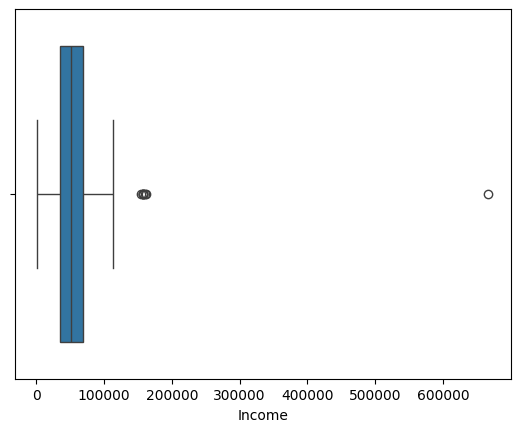

In [32]:
sns.boxplot(x=df["Income"])

In [33]:
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df[(df["Income"] < lower) | (df["Income"] > upper)]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
164,8475,1973,PhD,Married,157243.0,0,1,2014-03-01,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,0,0,0,0,3,11,0
617,1503,1976,PhD,Together,162397.0,1,1,2013-06-03,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,3,11,0
655,5555,1975,Graduation,Divorced,153924.0,0,0,2014-02-07,81,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,3,11,0
687,1501,1982,PhD,Married,160803.0,0,0,2012-08-04,21,55,16,1622,17,3,4,15,0,28,1,0,0,0,0,0,0,0,3,11,0
1300,5336,1971,Master,Together,157733.0,1,0,2013-06-04,37,39,1,9,2,0,8,0,1,0,1,1,0,0,0,0,0,0,3,11,0
1653,4931,1977,Graduation,Together,157146.0,0,0,2013-04-29,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,0,0,0,0,3,11,0
2132,11181,1949,PhD,Married,156924.0,0,0,2013-08-29,85,2,1,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,3,11,0
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,3,11,0


<Axes: xlabel='Income', ylabel='Count'>

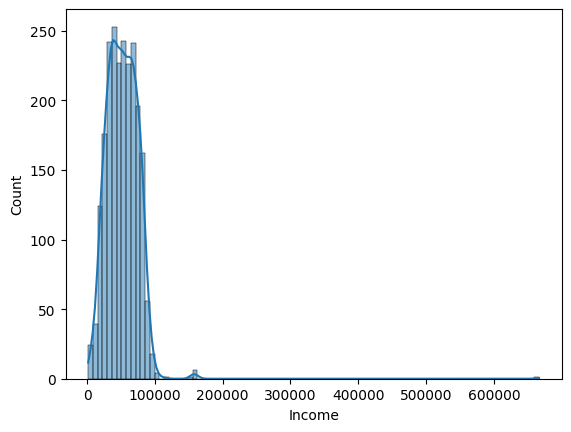

In [34]:
sns.histplot(df["Income"], kde=True)

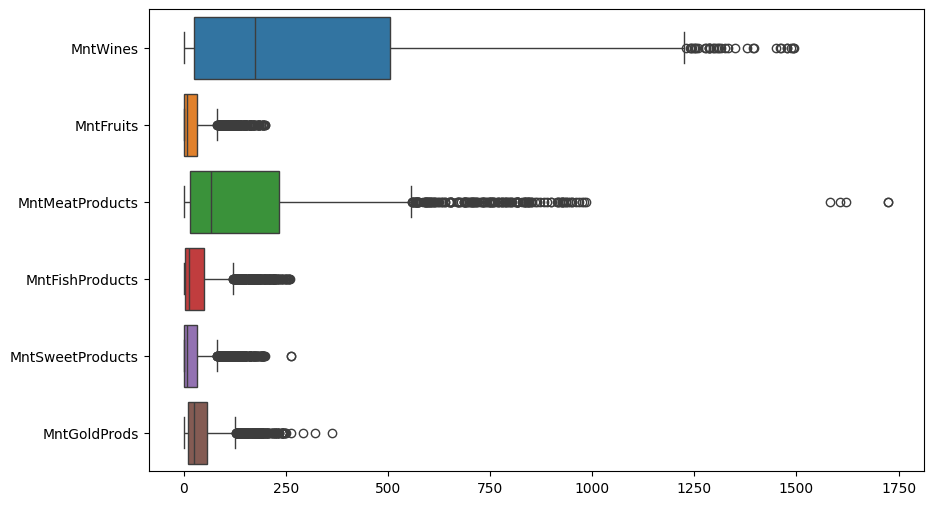

In [35]:
plt.figure(figsize=(10, 6)) # Increased height for clarity
sns.boxplot(data=df[["MntWines", "MntFruits", "MntMeatProducts", 
                     "MntFishProducts", "MntSweetProducts", "MntGoldProds"]], 
            orient="h")
plt.show()

In [36]:
df = df[df["Year_Birth"] > 1920]

Several outliers were observed, particularly in the Income and spending variables. For Income, these are very high but still possible. In customer datasets, rich customers exist. So, keeping them is the choice here, because removing them would bias the analysis. In terms of distribution, Income is right-skewed.

For spending variables, the same case stands as some customers buy a lot and others buy almost nothing. This is normal behavior. These outliers were retained in the dataset to preserve the natural variation in customer spending behavior.

An exception was made for unrealistic values in Year_Birth, which resulted in implausible customer ages (if we consider that the current year is 2026). These records were removed to ensure data quality.

## 4.6 Removing Unnecessary Variables

The variables ID, Z_CostContact and Z_Revenue were removed from the dataset because they contain constant values and do not contribute meaningful information to the analysis. Removing irrelevant variables helps streamline the dataset and ensures the analysis focuses only on meaningful features.

In [37]:
df.drop(["ID", "Z_CostContact", "Z_Revenue"], axis=1, inplace=True)

The Marital_Status column contains several categories describing the relationship status of customers. Two values, "Absurd" and "YOLO", appear in the dataset but represent unrealistic or non-meaningful categories.

In [38]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Because they occur only a few times and do not reflect valid marital statuses, these rows were removed from the dataset.

In [39]:
df = df[~df["Marital_Status"].isin(["Absurd", "YOLO"])]

After we finish cleaning our data, let's reset index to keep our dataset tidy.

In [40]:
df = df.reset_index(drop=True)

## 4.7 Cleaned Data
We have finished cleaning out data, now let's have a quick review of it.

In [41]:
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)]);

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'unique', 'uniqueSample'],
                     data=listItem)
print(df.shape)
dfDesc

(2233, 26)


,dataFeatures,dataType,null,unique,uniqueSample
0,Year_Birth,int64,0,56,"[1986, 1946]"
1,Education,object,0,5,"[Basic, Graduation]"
2,Marital_Status,object,0,6,"[Divorced, Alone]"
3,Income,float64,0,1971,"[27190.0, 60093.0]"
4,Kidhome,int64,0,3,"[0, 1]"
5,Teenhome,int64,0,3,"[1, 2]"
6,Dt_Customer,datetime64[ns],0,663,"[2013-09-01T00:00:00.000000000, 2013-12-31T00:00:00.000000000]"
7,Recency,int64,0,100,"[12, 75]"
8,MntWines,int64,0,775,"[451, 675]"
9,MntFruits,int64,0,158,"[199, 58]"


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is conducted to understand patterns, relationships, and trends within the dataset. This step helps uncover insights about customer demographics, purchasing behavior, and marketing campaign effectiveness.

The analysis focuses on several key aspects:
- Customer spending behavior across product categories
- Purchase channel preferences
- Marketing campaign effectiveness

## 5.1 Customer Spending by Product Category

Understanding which product categories generate the most spending can help the supermarket prioritize product promotion and inventory strategies.

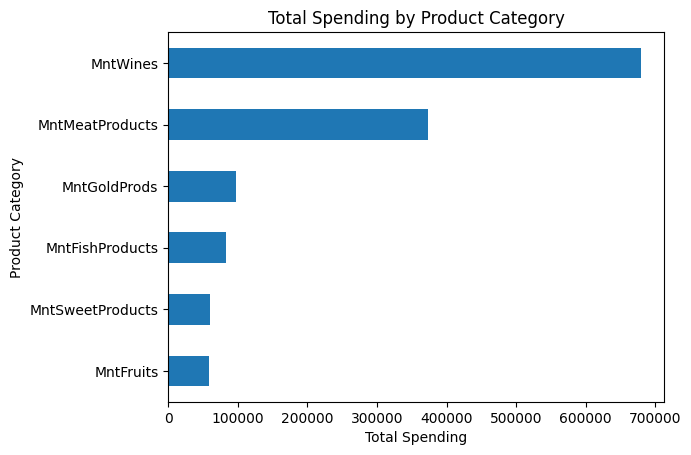

In [42]:
product_spending = df[[
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]].sum().sort_values()

product_spending.plot(kind="barh")
plt.title("Total Spending by Product Category")
plt.xlabel("Total Spending")
plt.ylabel("Product Category")
plt.show()

Interpretation

From the visualization, it can be observed that wine and meat products contribute the largest portion of customer spending, while fruits and sweet products contribute significantly less. This indicates that these categories may represent high-value product segments for the supermarket.

## 5.2 Purchase Channel Preference

Customers can make purchases through different channels, including web, catalog, and physical stores.

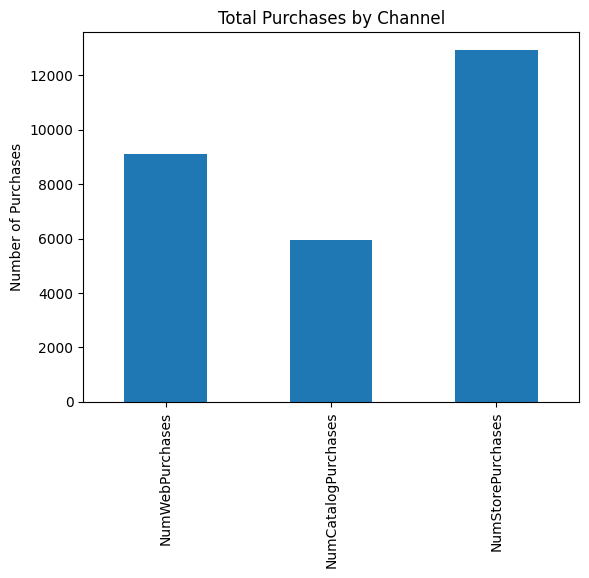

In [43]:
channels = df[[
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]].sum()

channels.plot(kind="bar")
plt.title("Total Purchases by Channel")
plt.ylabel("Number of Purchases")
plt.show()

Interpretation

The visualization shows that store purchases represent the largest share of transactions, followed by web purchases and catalog purchases. This suggests that physical stores remain the primary sales channel, although digital channels still play an important supporting role.

## 5.3 Marketing Campaign Acceptance

The dataset also includes information about customer responses to previous marketing campaigns.

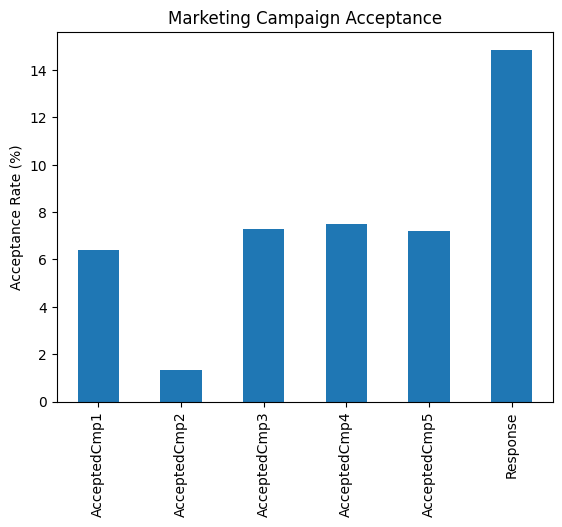

AcceptedCmp1     6.403941
AcceptedCmp2     1.343484
AcceptedCmp3     7.299597
AcceptedCmp4     7.478728
AcceptedCmp5     7.210031
Response        14.867891
dtype: float64

In [44]:
campaigns = df[[
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]].mean()*100

campaigns.plot(kind="bar")
plt.title("Marketing Campaign Acceptance")
plt.ylabel("Acceptance Rate (%)")
plt.show()

campaigns

Interpretation

The acceptance rates for most campaigns appear relatively low (1-7%). This suggests that many marketing campaigns may not be effectively targeting the right customers. However, the latest campaign shows a noticeably higher acceptance rate (~15%) compared to previous campaigns, which may indicate improvements in campaign targeting or marketing strategy.

# 6. Diagnostic Analysis

While exploratory analysis provides an overview of customer behavior, diagnostic analysis aims to identify potential factors that influence customer spending patterns. By examining relationships between demographic characteristics, purchasing behavior, and marketing responses, we can better understand what drives customer spending.

## 6.1 Income vs Customer Spending

Income is expected to influence purchasing power and overall spending behavior. A Total Spending variable was created by summing all product category spending columns. This variable represents the total amount spent by each customer across all product categories.

In [45]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

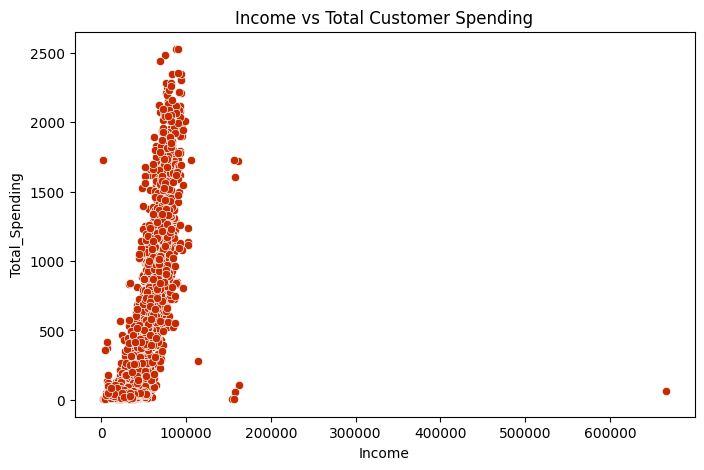

In [46]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Income", y="Total_Spending", data=df, color="#c62a00")
plt.title("Income vs Total Customer Spending")
plt.show()

To further validate the relationship, a correlation analysis was conducted between income and total spending. Given the relatively large dataset and the potential presence of non-normality and outliers, the Spearman correlation test was used.

Spearman correlation is a non-parametric method that does not assume a normal distribution and is more robust to outliers, making it suitable for measuring the strength and direction of the relationship between income and spending.

In [47]:
from scipy.stats import shapiro

stat, p = shapiro(df["Income"])
stat, p1 = shapiro(df["Total_Spending"])

print(p)
print(p1)

6.002901709301483e-48
3.0117501281251557e-40


In [48]:
from scipy.stats import spearmanr

corr, p = spearmanr(df["Income"], df["Total_Spending"])

print("Spearman correlation:", corr)
print("p-value:", p)

Spearman correlation: 0.8477559776909455
p-value: 0.0


Interpretation

The scatter plot shows a positive relationship between income and total spending, with correlation test showing strong relationship. Customers with higher income levels tend to spend more across product categories. This suggests that income is an important factor in customer segmentation and marketing targeting. 

## 6.2 Spending by Education Level

Customer education level may influence lifestyle and consumption patterns.

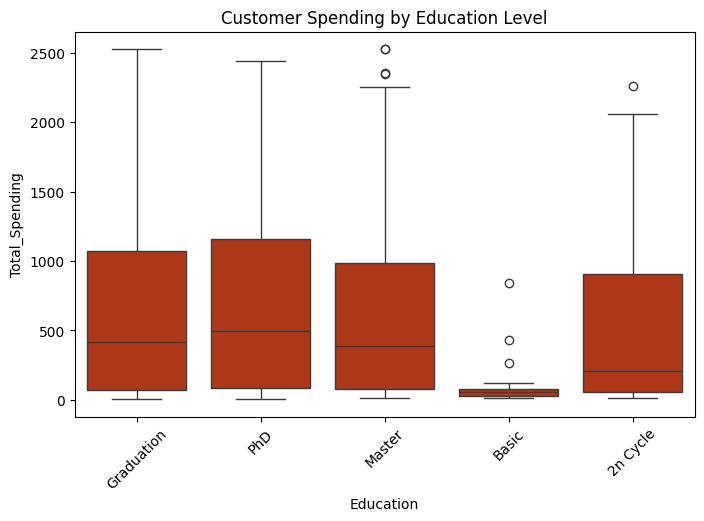

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Education", y="Total_Spending", data=df, color="#c62a00")
plt.xticks(rotation=45)
plt.title("Customer Spending by Education Level")
plt.show()

Interpretation

The distribution shows that customers with higher education levels tend to have higher median spending.  This suggests that education may have some influence on spending behavior. Basic education shows significant difference total spending level with other education levels. Let's see the counts for each education level.

In [50]:
edu_counts = df['Education'].value_counts().reset_index()
edu_counts.columns = ['Education', 'Count']

# Add percentage
edu_counts['Percentage'] = (edu_counts['Count'] / edu_counts['Count'].sum() * 100).round(2)

display(edu_counts)

,Education,Count,Percentage
0,Graduation,1126,50.43
1,PhD,483,21.63
2,Master,369,16.52
3,2n Cycle,201,9.00
4,Basic,54,2.42


Interpretation

Most customers have higher levels of education, while those with basic education represent only a small proportion of the dataset (approximately 2.42%), making them negligible. Although this observation is noted, education level will not be included as a key variable in the customer segmentation due to its limited impact.

## 6.3 Spending by Marital Status

Household structure may affect purchasing patterns and total spending.

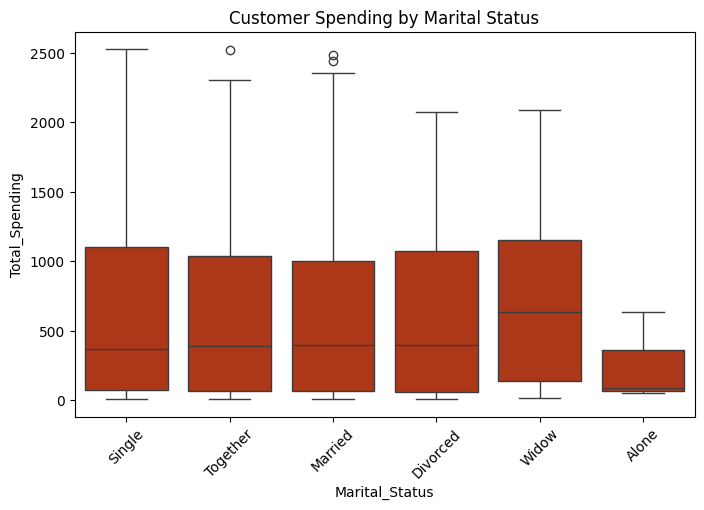

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Marital_Status", y="Total_Spending", data=df, color="#c62a00")
plt.xticks(rotation=45)
plt.title("Customer Spending by Marital Status")
plt.show()

To simplify the analysis, marital status categories are grouped into Partnered and Single. Customers labeled as “Together” exhibit spending behavior similar to those who are “Married,” while “Divorced” and “Widow” groups behave similarly to “Single” individuals.

The “Alone” category shows some differences in total spending, so it will be further examined.

In [52]:
alone_count = (df['Marital_Status'] == 'Alone').sum()
print(f"Number of 'Alone' rows: {alone_count}")

Number of 'Alone' rows: 3


"Alone" has very few entries. In statistics, such a small sample size makes it impossible to draw reliable conclusions. Grouping "Alone" into "Single" will give those data points more weight.

In [53]:
mappingMarital = {
    'Married': 'Partnered',
    'Together': 'Partnered',
    'Single': 'Single',
    'Divorced': 'Single',
    'Widow': 'Single',
    'Alone': 'Single'
}

df['Marital_Status_Group'] = df['Marital_Status'].map(mappingMarital)

After separating them into two groups, let's compare their spending.

In [54]:
from scipy.stats import mannwhitneyu

spent_partnered = df[df['Marital_Status_Group'] == 'Partnered']['Total_Spending']
spent_single = df[df['Marital_Status_Group'] == 'Single']['Total_Spending']

stat, p_val = mannwhitneyu(spent_partnered, spent_single)

print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically Significant. Relationship status affects total spending.")
else:
    print("Result: Not Significant. Marital status does not appear to drive total spending.")

P-value: 0.5485
Result: Not Significant. Marital status does not appear to drive total spending.


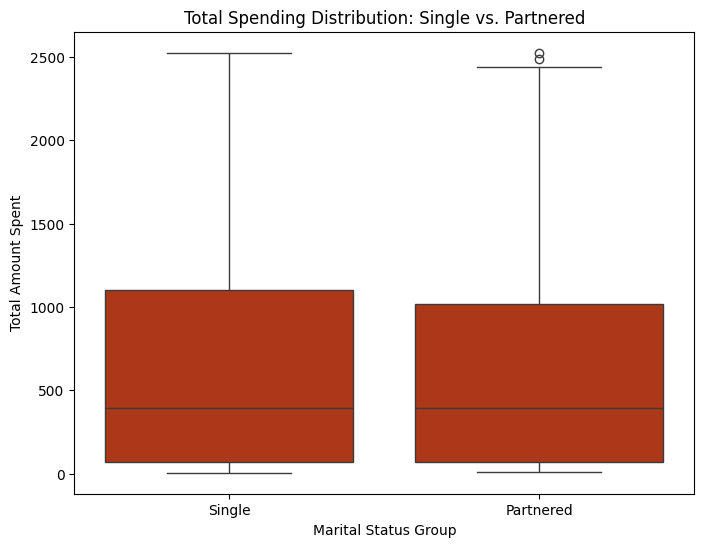

In [55]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Marital_Status_Group', y='Total_Spending', data=df, color="#c62a00")
plt.title('Total Spending Distribution: Single vs. Partnered')
plt.ylabel('Total Amount Spent')
plt.xlabel('Marital Status Group')
plt.show()

Interpretation

Marital status (Single vs. Partnered) shows a negligible impact on total spending.

## 6.4 Spending based on Children in Families

Families with children might spend differently, so let's check how this affects spending. Children variable was created by combining the number of children and teenagers in the household. These derived variables help simplify the analysis and provide clearer insights into customer spending behavior.

In [56]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

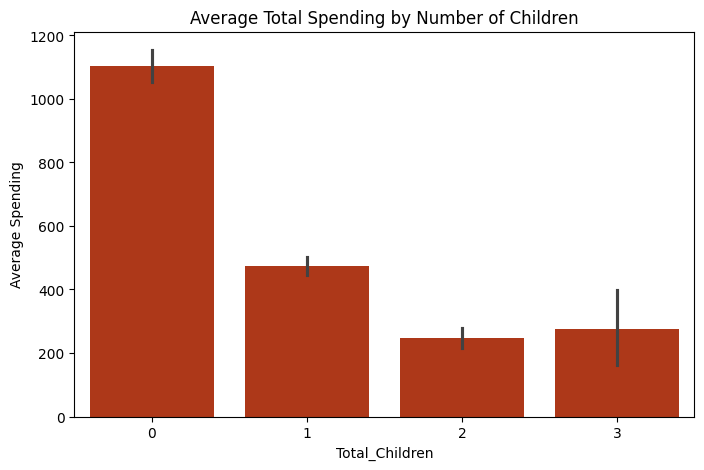

In [57]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Total_Children', y='Total_Spending', data=df, estimator='mean', color="#c62a00")
plt.title('Average Total Spending by Number of Children')
plt.ylabel('Average Spending')
plt.show()

Interpretation

While marital status (Single vs. Partnered) has a negligible impact on spending, household size (children) is a primary driver of purchasing behavior. Customers with no children spend significantly more on our product categories than those with 1 or more children.

## 6.5 Groupings

Now that the key variables and their relationships have been explored, the next step is to create customer groupings to support segmentation for a more targeted marketing approach.

This segmentation focuses on three primary variables: income, total spending, and household composition (presence of children), as these factors have been identified as key drivers of differences in customer behavior.

Customers are categorized into three levels: low, medium, and high, for both income and spending to capture variations in customer value. In addition, a children flag is used to distinguish between customers with and without children, allowing for further differentiation based on household structure.

This grouping approach enables the identification of distinct customer segments with unique characteristics, which will be used to inform more effective and targeted marketing strategies.

In [58]:
# Income grouping
df['Income_Group'] = pd.qcut(df['Income'], q=3, labels=['Low', 'Medium', 'High'])

# Spending grouping
df['Spending_Group'] = pd.qcut(df['Total_Spending'], q=3, labels=['Low', 'Medium', 'High'])

# Children flag
df['Has_Children'] = df['Total_Children'].apply(lambda x: 'Yes' if x > 0 else 'No')

## 6.6 Customer Segmentation

By creating these groups, we can identify which customer segments demonstrate the highest spending and strongest response to marketing campaigns. The segments are primarily evaluated based on total spending, as it is the most significant indicator of customer value.

In addition, we analyze the number of customers in each segment to assess whether the segment is large enough to justify a targeted marketing approach.

In [59]:
segment_summary = df.groupby(
    ['Income_Group', 'Spending_Group', 'Has_Children']
).agg({
    'Total_Spending': 'mean',
    'Response': 'mean',
    'Income_Group': 'count'   # count rows = number of customers
}).rename(columns={'Income_Group': 'Customer_Count'}).reset_index()

# Sort to see highest value segments
segment_summary = segment_summary.sort_values(by='Total_Spending', ascending=False)

print("=== SEGMENT SUMMARY ===")
display(segment_summary)

=== SEGMENT SUMMARY ===


,Income_Group,Spending_Group,Has_Children,Total_Spending,Response,Customer_Count
5,Low,High,Yes,1730.000000,0.000000,1
16,High,High,No,1484.117359,0.330073,409
17,High,High,Yes,1256.700980,0.127451,204
10,Medium,High,No,1207.875000,0.312500,32
11,Medium,High,Yes,1055.666667,0.135417,96
4,Low,High,No,837.000000,0.500000,2
14,High,Medium,No,690.206897,0.206897,29
15,High,Medium,Yes,587.427083,0.052083,96
9,Medium,Medium,Yes,413.547847,0.105263,418
8,Medium,Medium,No,403.127660,0.106383,47


Interpretation

Based on the table, several key insights can be derived:

1. High-spending segments consistently appear at the top, and are generally associated with higher income levels, followed by medium- and low-income groups. In contrast, the presence of children is more evenly distributed across segments and does not follow a clear pattern.
2. Customer count is a critical consideration when evaluating segments. Segments with very small populations should be excluded from targeted strategies, as they are likely to have limited impact on overall business performance.

In [60]:
# Filter meaningful segments
important_segments = segment_summary[
    (segment_summary['Customer_Count'] > 50)
]

display(important_segments.sort_values(by='Total_Spending', ascending=False))

,Income_Group,Spending_Group,Has_Children,Total_Spending,Response,Customer_Count
16,High,High,No,1484.117359,0.330073,409
17,High,High,Yes,1256.700980,0.127451,204
11,Medium,High,Yes,1055.666667,0.135417,96
15,High,Medium,Yes,587.427083,0.052083,96
9,Medium,Medium,Yes,413.547847,0.105263,418
3,Low,Medium,Yes,238.008696,0.226087,115
7,Medium,Low,Yes,56.126667,0.013333,150
0,Low,Low,No,50.306667,0.080000,75
1,Low,Low,Yes,49.772374,0.093385,514


Intrepretation

With this cleaner segment summary, it is easier to understand the case. It is best to focus on few segments rather than lots of segments, so three segments are used. They are:
1. High Value Childless. The high-income, high-spending customers without children represent the most valuable segment, with the highest average spending (≈1484) and the strongest campaign response rate (≈33%). In addition, this segment has a large customer base (409 customers), making it both high-value and highly responsive to marketing efforts.
2. High Value Family. High-income customers with children also demonstrate strong spending behavior (≈1257), but their campaign response rate is significantly lower (≈13%) despite having a substantial customer base (204 customers). This suggests that while they contribute high revenue, they are less responsive to current marketing strategies.
3. Medium Value. Customers in the medium spending segment, regardless of income level, show moderate purchasing behavior (≈238–587 range depending on subgroup) with varied campaign response rates (≈5–22%). Despite having a sizable customer base, their engagement with marketing campaigns remains limited.

In [61]:
def assign_segment(row):
    if row['Income_Group'] == 'High' and row['Spending_Group'] == 'High' and row['Has_Children'] == 'No':
        return 'High Value Childless'
    elif row['Spending_Group'] == 'High':
        return 'High Value Family'
    elif row['Spending_Group'] == 'Medium':
        return 'Medium Value'

df['Customer_Segment'] = df.apply(assign_segment, axis=1)

In [62]:
segment_profile = df.groupby('Customer_Segment').agg({
    'Total_Spending': 'mean',
    'Response': 'mean'
}).sort_values(by='Total_Spending', ascending=False)

print("\n=== SEGMENT PROFILE ===")
display(segment_profile)


=== SEGMENT PROFILE ===


,Total_Spending,Response
Customer_Segment,,
High Value Childless,1484.117359,0.330073
High Value Family,1193.334328,0.149254
Medium Value,412.946164,0.122476


## 6.7 Segmentation Validation

It is a considered best practice to validate customer segments by checking them against original parameters. 

In [63]:
# Select product columns
product_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

# Average spending per segment
segment_product_spending = df.groupby('Customer_Segment')[product_cols].mean()
segment_product_pct = (segment_product_spending.div(
    segment_product_spending.sum(axis=1), axis=0
) * 100).round(2)

print("\n=== PRODUCT SPENDING DISTRIBUTION (%) ===")
display(segment_product_pct)

# Identify top product per segment
top_products = segment_product_spending.idxmax(axis=1)

print("\n=== TOP PRODUCT PER SEGMENT ===")
display(top_products)


=== PRODUCT SPENDING DISTRIBUTION (%) ===


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Customer_Segment,,,,,,
High Value Childless,44.45,4.47,34.90,6.51,4.60,5.07
High Value Family,57.83,4.01,21.76,5.53,4.15,6.72
Medium Value,53.56,4.24,21.14,5.97,4.38,10.71



=== TOP PRODUCT PER SEGMENT ===


Customer_Segment
High Value Childless    MntWines
High Value Family       MntWines
Medium Value            MntWines
dtype: object

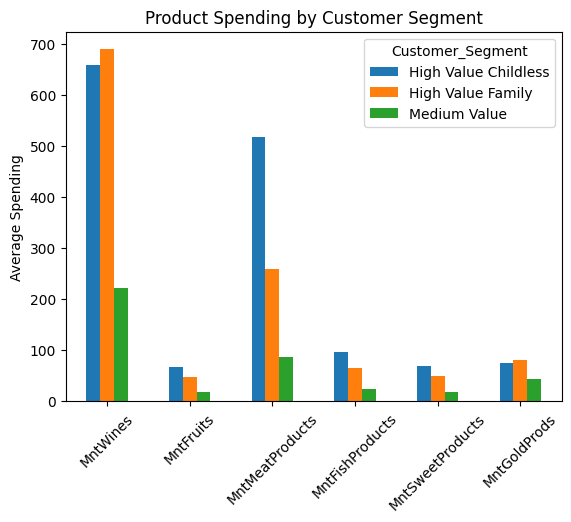

In [64]:
import matplotlib.pyplot as plt

segment_product_spending.T.plot(kind='bar')
plt.title("Product Spending by Customer Segment")
plt.ylabel("Average Spending")
plt.xticks(rotation=45)
plt.show()

Based on product spending across customer segments, several key insights and recommended actions can be identified:

1. Wine and meat products consistently account for the highest share of customer spending. This suggests that both categories are major revenue drivers. Further analysis may be conducted to evaluate whether there is a correlation between purchases of these two categories, which could inform bundling strategies.
2. High-value, childless customers allocate a significant portion of their spending to meat products. To better serve this segment, the supermarket can introduce smaller, premium-sized portions. This reduces concerns about waste while allowing for higher price-per-unit positioning, ultimately improving profit margins.
3. Strengthen focus on core product categories. Given that wine and meat represent the supermarket’s strongest revenue contributors, the company should continue to prioritize and optimize these categories through targeted promotions, product variety, and premium offerings.

Spearman Correlation: 0.8237
P-value: 0.0000e+00


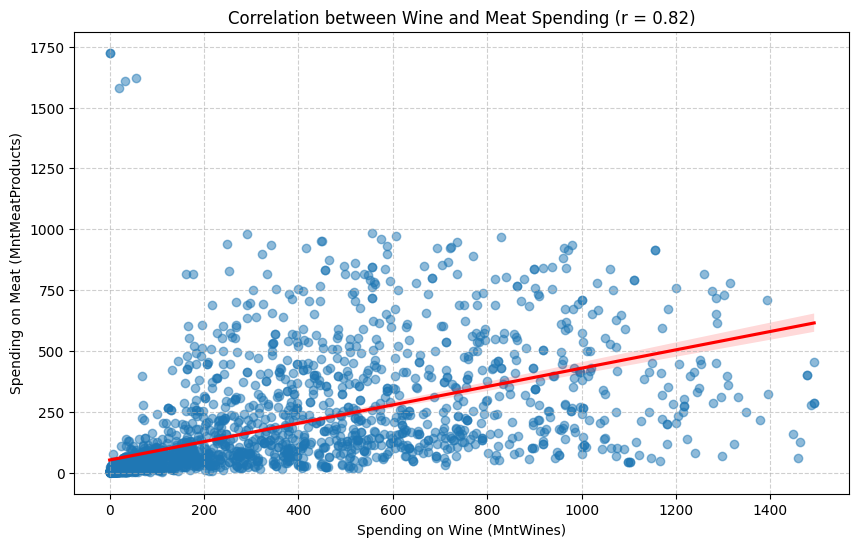

In [65]:
# Calculate the Spearman Correlation and P-value
correlation, p_value = spearmanr(df['MntWines'], df['MntMeatProducts'])

print(f"Spearman Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4e}")

# Visualize the relationship with a Regression Plot
plt.figure(figsize=(10, 6))
sns.regplot(x='MntWines', y='MntMeatProducts', data=df, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title(f'Correlation between Wine and Meat Spending (r = {correlation:.2f})')
plt.xlabel('Spending on Wine (MntWines)')
plt.ylabel('Spending on Meat (MntMeatProducts)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Interpretation

Statistical analysis shows a significant positive correlation ($r$ = 0.8237, $p$ < 0.05) between Wine and Meat expenditure. This confirms that these categories are complementary, providing a data-driven justification for a 'Premium Gourmet Bundle' targeting high-income segments."

After knowing what products segmented customers buy, let's check on how they buy the products.

In [66]:
# Select channel columns
channel_cols = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

# Average channel usage per segment
channel_usage = df.groupby('Customer_Segment')[channel_cols].mean()
channel_pct = (channel_usage.div(channel_usage.sum(axis=1), axis=0)*100).round(2)

print("\n=== CHANNEL DISTRIBUTION (%) ===")
display(channel_pct)

# Find dominant channel per segment
top_channel = channel_usage.idxmax(axis=1)

print("\n=== DOMINANT CHANNEL PER SEGMENT ===")
display(top_channel)


=== CHANNEL DISTRIBUTION (%) ===


,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Customer_Segment,,,
High Value Childless,24.94,31.81,43.26
High Value Family,32.53,24.38,43.09
Medium Value,38.47,15.74,45.79



=== DOMINANT CHANNEL PER SEGMENT ===


Customer_Segment
High Value Childless    NumStorePurchases
High Value Family       NumStorePurchases
Medium Value            NumStorePurchases
dtype: object

Interpretation

The results show similar approach, where customers are inclined more to purchase directly at the store, but if we see the distribution, we can see that web purchases from website channel attracted a competitive amount of our Medium Value customers as well.

The last to consider is to know when our customers buy our product, by using recency test on our segmented customers.

In [67]:
# Average recency per segment
recency_summary = df.groupby('Customer_Segment').agg(
    Avg_Recency=('Recency', 'mean'),
    Customer_Count=('Education', 'count')
).reset_index()

# Sort by recency (lower = more recent activity)
recency_summary = recency_summary.sort_values(by='Avg_Recency')

print("=== RECENCY BY CUSTOMER SEGMENT ===")
display(recency_summary)

=== RECENCY BY CUSTOMER SEGMENT ===


,Customer_Segment,Avg_Recency,Customer_Count
2,Medium Value,48.406460,743
0,High Value Childless,49.334963,409
1,High Value Family,51.671642,335


Interpretation

The table shows no recency difference among all customer segments.

# 7. Conclusion

Based on the data analysis, several key insights can be identified.

Insight 1: Income and Household Composition Are the Primary Drivers of Spending

Customers with higher income levels consistently show higher spending across product categories. Additionally, household composition plays a significant role, with customers without children generally exhibiting higher spending compared to those with children. This indicates that income and household structure are key variables for segmentation.

Insight 2: Distinct High-Value Segments Show Different Campaign Responsiveness

High-income customers without children represent the most valuable segment, combining high spending with strong campaign response (~33%). In contrast, high-income customers with children also generate high spending but show significantly lower campaign response (~13%). This shows that high-value customers are not homogeneous and require different marketing approaches.

Insight 3: Spending Does Not Guarantee Engagement

Customers with high or moderate spending levels do not always respond well to marketing campaigns. This suggests that spending alone is insufficient for targeting. Campaign responsiveness must be included in segmentation.

Insight 4: Wine and Meat Products Drive Revenue Across Segments

Wine and meat products contribute the largest share of total spending, making them key revenue drivers. These categories can be used strategically in segment-specific promotions and bundling strategies.

# 8. Business Recommendations

Based on the insights derived from the analysis, several business recommendations can be proposed.

1. Implement Segmentation-Based Marketing Strategy

The supermarket should adopt a customer segmentation approach based on demographics, purchasing behavior, and campaign responsiveness. By replacing one-size-fits-all campaigns with segment-specific strategies, the company can improve targeting accuracy, increase engagement, and maximize marketing ROI.

2. Maximize High-Value, High-Response Segment (Childless Customers)

This segment represents the most valuable customers due to both high spending and strong campaign responsiveness. The recommended actions are to develop loyalty programs and personalized premium offers, introduce premium product bundles (e.g., wine and meat in smaller, high-quality portions), and maintain engagement through exclusive or limited-time promotions.

3. Improve Engagement for High-Value Families

Although this segment contributes high spending, their campaign response is relatively low, indicating untapped potential. The recommended actions are to offer family-oriented promotions and value bundles, introduce larger-size bundles for key categories (e.g., wine and meat), and use more relevant and practical messaging tailored to family needs.

4. Activate Medium-Spending Segment as a Growth Opportunity

Medium-spending customers represent a large segment with moderate purchasing activity but low engagement, making them a key growth driver. The recommended actions are to use targeted discounts and personalized promotions and apply upselling strategies to increase basket size.